#self derivative

In [101]:
def dy_dx(x):
  return 2*x

In [102]:
dy_dx(3)

6

#Derivative using Autograd

In [103]:
import torch

In [104]:
x=torch.tensor(3.0,requires_grad=True)

In [105]:
x

tensor(3., requires_grad=True)

In [106]:
y=x**2

In [107]:
y

tensor(9., grad_fn=<PowBackward0>)

In [108]:
y.backward()

In [109]:
x.grad

tensor(6.)

#  derivative  of
   1.y=x^2
   2.y=x^2,z=sin(y)


In [110]:
import math
def dz_dx(x):
    return 2*x*math.cos(x**2)

In [111]:
dz_dx(4)

-7.661275842587077

# Using Autograd

In [112]:
x=torch.tensor(3.0,requires_grad=True)


In [113]:
y=x**2

In [114]:
y

tensor(9., grad_fn=<PowBackward0>)

In [115]:
z=torch.sin(y)

In [116]:
x

tensor(3., requires_grad=True)

In [117]:
z

tensor(0.4121, grad_fn=<SinBackward0>)

In [118]:
z.backward()

In [119]:
x.grad

tensor(-5.4668)

In [120]:
y.grad

/tmp/ipykernel_1076/486760323.py:1: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more information. (Triggered internally at /pytorch/build/aten/src/ATen/core/TensorBody.h:494.)
  y.grad


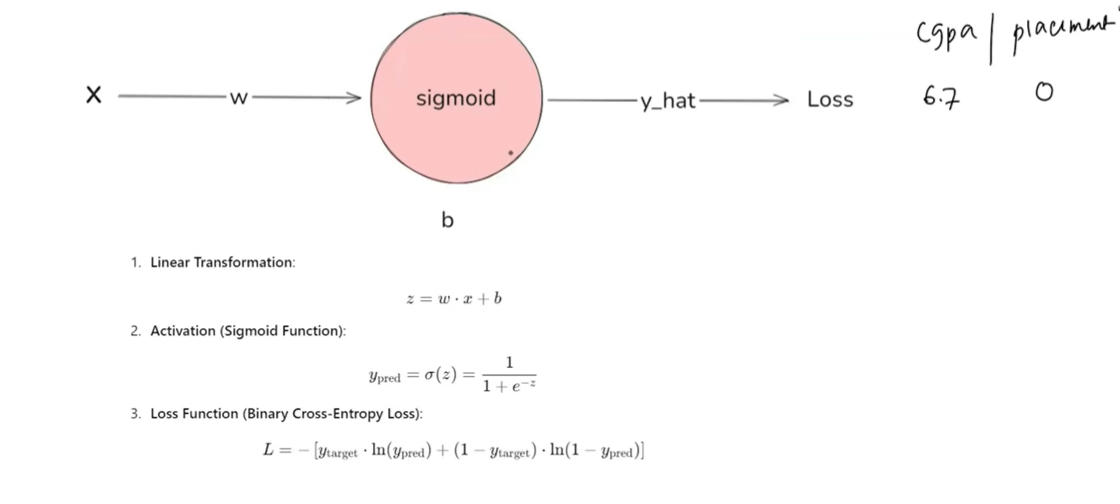

#manual gradient and loss calculation

In [121]:
import torch
x=torch.tensor(6.7)
y=torch.tensor(0.0)

w=torch.tensor(1.0)
b=torch.tensor(0.0)

In [122]:
def binary_cross_entropy_loss(prediction,target):
   epsilon=1e-8
   prediction=torch.clamp(prediction,epsilon,1-epsilon)
   return -(target*torch.log(prediction)+(1-target)*torch.log(1-prediction))


In [123]:
Z=w*x+b
y_pred=torch.sigmoid(z)

loss=binary_cross_entropy_loss(y_pred,y)
print(loss)

tensor(0.9203, grad_fn=<NegBackward0>)


In [124]:
dloss_dy_pred=(y_pred-y)/(y_pred*(1-y_pred))

dy_pred_dz=y_pred*(1-y_pred)

dz_dw=x
dz_db=1

dloss_dw=dloss_dy_pred*dy_pred_dz*dz_dw
dloss_db=dloss_dy_pred*dy_pred_dz*dz_db

print(dloss_dw)
print(dloss_db)


tensor(4.0307, grad_fn=<MulBackward0>)
tensor(0.6016, grad_fn=<MulBackward0>)


#using PyTorch Autograd

#task 2

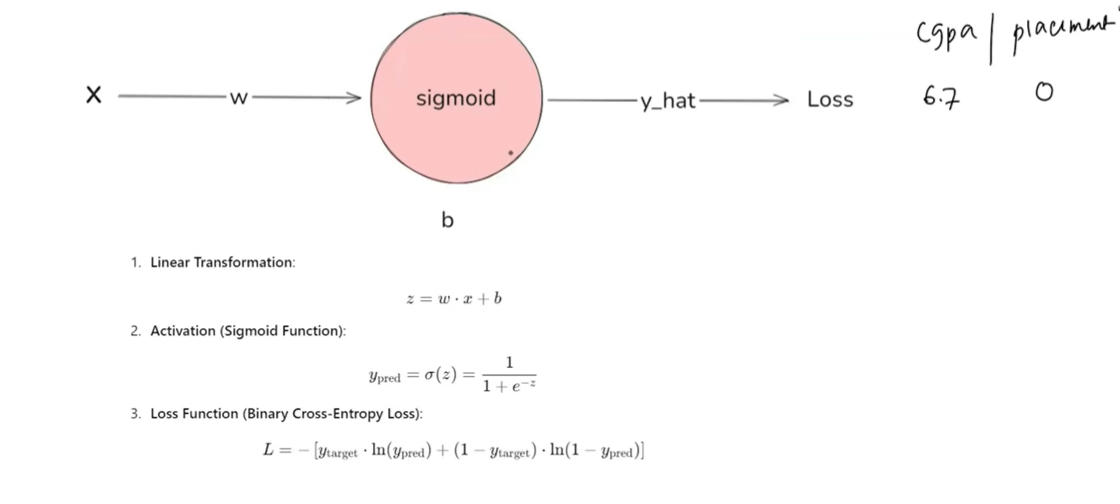


#Computational graph
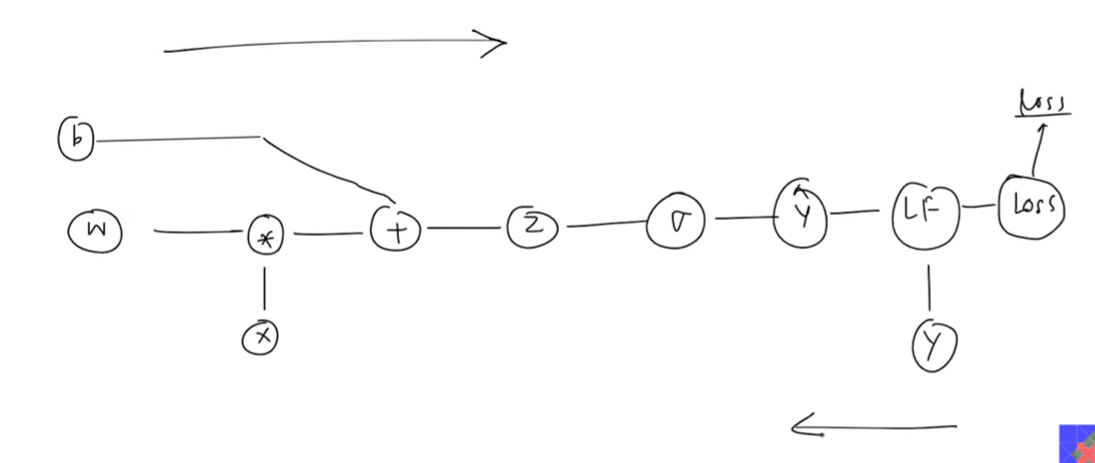

In [125]:
x=torch.tensor(6.7)
y=torch.tensor(0.0)


In [126]:
w=torch.tensor(1.0,requires_grad=True)
b=torch.tensor(0.0,requires_grad=True)

In [127]:
w

tensor(1., requires_grad=True)

In [128]:
b

tensor(0., requires_grad=True)

In [129]:
z=w*x+b

In [130]:
z

tensor(6.7000, grad_fn=<AddBackward0>)

In [131]:
y_pred=torch.sigmoid(z)
y_pred

tensor(0.9988, grad_fn=<SigmoidBackward0>)

In [132]:
loss=binary_cross_entropy_loss(y_pred,y)
loss

tensor(6.7012, grad_fn=<NegBackward0>)

In [133]:
loss.backward()

In [134]:
print(w.grad)
print(b.grad)

tensor(6.6918)
tensor(0.9988)


In [135]:
x=torch.tensor([1.0,2.0,3.0],requires_grad=True)

In [141]:
x

tensor([1., 2., 3.], requires_grad=True)

In [142]:
y=(x**2).mean()

In [143]:
y

tensor(4.6667, grad_fn=<MeanBackward0>)

In [145]:
y.backward()

#clear gradient

In [154]:
x=torch.tensor(2.0,requires_grad=True)
x

tensor(2., requires_grad=True)

In [165]:
y=x**2
y

tensor(4., grad_fn=<PowBackward0>)

In [166]:
y.backward()

In [167]:
x.grad

tensor(8.)

In [170]:
x.grad
print(x.grad)

tensor(0.)


In [169]:
x.grad.zero_()

tensor(0.)

#disable gradient tracking

In [173]:

x=torch.tensor(2.0,requires_grad=True)
x

tensor(2., requires_grad=True)

In [174]:
y=x**2
y

tensor(4., grad_fn=<PowBackward0>)

In [175]:
y.backward()

In [176]:
x.grad

tensor(4.)

In [ ]:
# option 1 -requires_grad_(false)
#option 2 -datach()
#option 3-torch.no_grad()

In [177]:
x.requires_grad_(False)

tensor(2.)

In [178]:
x

tensor(2.)

In [180]:
y=x**2
y

tensor(4.)

In [181]:
y.backward()

RuntimeError: element 0 of tensors does not require grad and does not have a grad_fn

In [182]:
x=torch.tensor(2.0,requires_grad=True)
x

tensor(2., requires_grad=True)

In [183]:
z = x.detach()
z

tensor(2.)

In [184]:
y = x ** 2

In [185]:
y

tensor(4., grad_fn=<PowBackward0>)

In [186]:
y1 = z ** 2
y1

tensor(4.)

In [188]:
y.backward()

RuntimeError: Trying to backward through the graph a second time (or directly access saved tensors after they have already been freed). Saved intermediate values of the graph are freed when you call .backward() or autograd.grad(). Specify retain_graph=True if you need to backward through the graph a second time or if you need to access saved tensors after calling backward.

In [189]:
x = torch.tensor(2.0, requires_grad=True)
x

tensor(2., requires_grad=True)

In [190]:
y = x ** 2

In [191]:
y

tensor(4., grad_fn=<PowBackward0>)

In [192]:
y.backward()